## Data

In [1]:
from simulator import simulate

print(simulate([1.0, 0.0]))

0.4166666666666668


/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/festim/coupled_heat_hydrogen_problem.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  import tqdm.autonotebook


In [2]:
import numpy as np

n_samples = 100
x = np.random.rand(n_samples, 2) * 10
x

array([[9.86490380e+00, 7.80641855e+00],
       [2.83639533e+00, 3.19772105e+00],
       [7.28565296e+00, 7.17239189e+00],
       [1.49837767e+00, 7.46756167e+00],
       [2.40102753e+00, 2.78230146e+00],
       [6.18102180e+00, 9.81591077e+00],
       [5.24521452e+00, 5.14217369e+00],
       [1.09003514e+00, 1.66719902e+00],
       [2.93614272e+00, 3.39886743e+00],
       [2.39454744e+00, 8.79011029e+00],
       [5.87336534e+00, 3.46385272e+00],
       [3.49550330e+00, 6.10115168e+00],
       [2.98405793e-01, 1.90492739e+00],
       [9.19784974e+00, 6.92389961e+00],
       [4.03493528e+00, 2.50463404e+00],
       [6.86588514e-01, 4.40280508e+00],
       [1.89348854e+00, 6.37081346e+00],
       [4.47344227e+00, 2.00127807e+00],
       [3.22435871e+00, 7.40707320e+00],
       [3.06067588e-01, 1.38657157e+00],
       [9.77471608e+00, 2.42041030e-01],
       [7.47698864e+00, 7.05767007e+00],
       [7.28031362e+00, 7.78974187e+00],
       [8.28235537e+00, 2.30426452e+00],
       [2.576144

In [3]:
y = np.array([simulate(xi) for xi in x])
y

array([8.66412074, 3.04716867, 7.21958401, 4.98040167, 2.62343732,
       8.3013737 , 5.18510737, 1.42671407, 3.20606547, 6.12529244,
       4.46781631, 5.01546485, 1.23554339, 7.87137883, 3.14225956,
       2.85438151, 4.50526141, 3.03134649, 5.66427549, 0.93636158,
       4.21398897, 7.23238614, 7.5774801 , 4.79513571, 6.53003399,
       5.72611369, 5.43383503, 3.62454091, 2.46189906, 3.26405226,
       3.073047  , 4.95133435, 6.39499551, 2.99401418, 1.55597754,
       3.37496572, 2.66425604, 4.18037338, 7.2750787 , 5.08227457,
       1.77875423, 4.92004647, 5.31647845, 4.05039816, 2.36173993,
       5.27539621, 6.55429308, 5.73824745, 4.77469171, 2.5077667 ,
       6.55289642, 6.16062907, 6.43798253, 3.90313889, 7.15254404,
       6.66838136, 5.38095628, 3.89174714, 7.65235934, 5.95327228,
       1.92650478, 3.35585029, 3.94708716, 5.9077031 , 3.57759925,
       3.8077928 , 5.47411536, 9.21342452, 4.72471667, 4.06892235,
       2.81431851, 7.06990546, 8.26391399, 5.725654  , 4.75269

In [4]:
# make sure x and y are pytorch tensors
import torch
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
x.shape, y.shape

(torch.Size([100, 2]), torch.Size([100]))

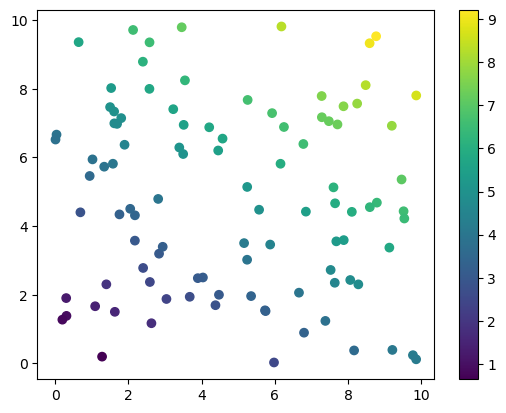

In [5]:
import matplotlib.pyplot as plt

plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.show()

## Build emulator

In [6]:
from autoemulate import AutoEmulate

AutoEmulate.list_emulators()

,Emulator,PyTorch,Multioutput,Uncertainty_Quantification,Automatic_Differentiation
0,GaussianProcessMatern32,True,True,True,True
1,GaussianProcessRBF,True,True,True,True
2,RadialBasisFunctions,True,True,False,True
3,PolynomialRegression,True,True,False,True
4,MLP,True,True,False,True
5,EnsembleMLP,True,True,True,True


In [7]:
# Run AutoEmulate with default settings
ae = AutoEmulate(x, y, log_level="info")

INFO    2026-01-15 14:41:56,156 - autoemulate - Comparing ['GaussianProcessMatern32', 'GaussianProcessRBF', 'RadialBasisFunctions', 'PolynomialRegression', 'MLP', 'EnsembleMLP']
INFO    2026-01-15 14:41:56,157 - autoemulate - Running Model: GaussianProcessMatern32: 1/6 (attempt 1/3)
INFO    2026-01-15 14:42:10,348 - autoemulate - Finished running Model: GaussianProcessMatern32

INFO    2026-01-15 14:42:10,349 - autoemulate - Running Model: GaussianProcessRBF: 2/6 (attempt 1/3)
WARNING 2026-01-15 14:42:13,018 - py.warnings - /home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/autoemulate/emulators/gaussian_process/exact.py:295: NumericalWarning: cov not p.d. - added 1.0e-04 to the diagonal and symmetrized
  make_positive_definite(

WARNING 2026-01-15 14:42:13,139 - py.warnings - /home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/autoemulate/emulators/gaussian_process/exact.py:295: NumericalWarning: cov not p.d. - added 1.0e-05 to the diagonal a

In [8]:
ae.summarise()

,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
3,PolynomialRegression,[StandardizeTransform()],[StandardizeTransform()],"{'lr': 0.2, 'epochs': 500, 'batch_size': 32, '...",1.000000,0.000000,2.206339e-06,3.025709e-07,1.000000,0.000000e+00,1.445965e-06,7.501050e-08
2,RadialBasisFunctions,[StandardizeTransform()],[StandardizeTransform()],"{'kernel': 'linear', 'degree': 1, 'smoothing':...",1.000000,0.000000,3.071899e-07,8.192854e-08,1.000000,0.000000e+00,3.258476e-07,3.203964e-08
0,GaussianProcessMatern32,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 100, 'lr': 0.5, 'likelihood_cls': <...",0.999996,0.000003,3.538369e-03,9.013481e-04,0.999999,1.704924e-07,1.506225e-03,2.264142e-04
1,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 50, 'lr': 0.5, 'likelihood_cls': <c...",0.999993,0.000002,4.796445e-03,1.037900e-03,0.999994,1.005582e-06,4.563626e-03,5.064973e-04
5,EnsembleMLP,[StandardizeTransform()],[StandardizeTransform()],"{'n_emulators': 6, 'epochs': 100, 'layer_dims'...",0.999891,0.000067,1.684843e-02,2.799107e-03,0.999983,3.382990e-06,7.822178e-03,5.819632e-04
4,MLP,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 100, 'layer_dims': [8, 4], 'lr': 0....",0.996343,0.002133,1.064086e-01,4.126896e-02,0.997622,1.351218e-03,8.894897e-02,2.788189e-02


In [9]:
# best = ae.best_result()
best = ae.results[0]
print("Model with id: ", best.id, " performed best: ", best.model_name)

Model with id:  0  performed best:  GaussianProcessMatern32


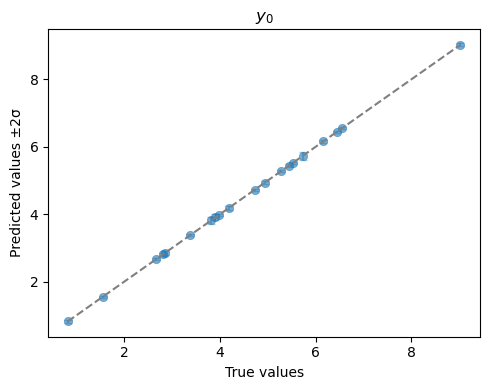

In [10]:
ae.plot_preds(best)

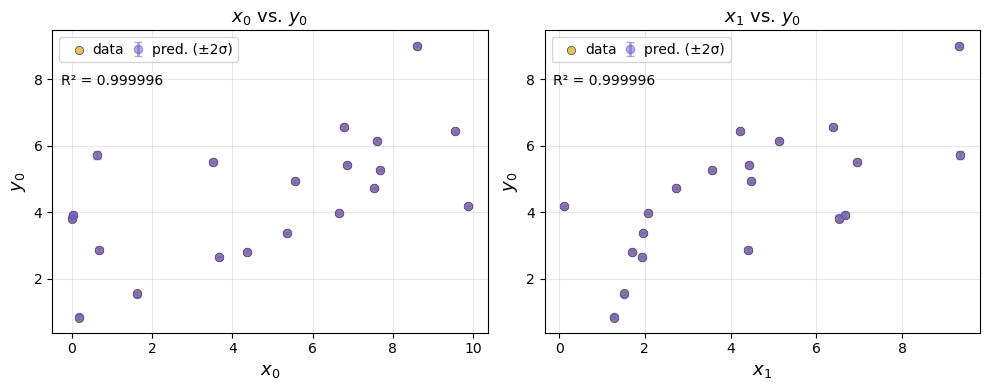

In [11]:
ae.plot(best)

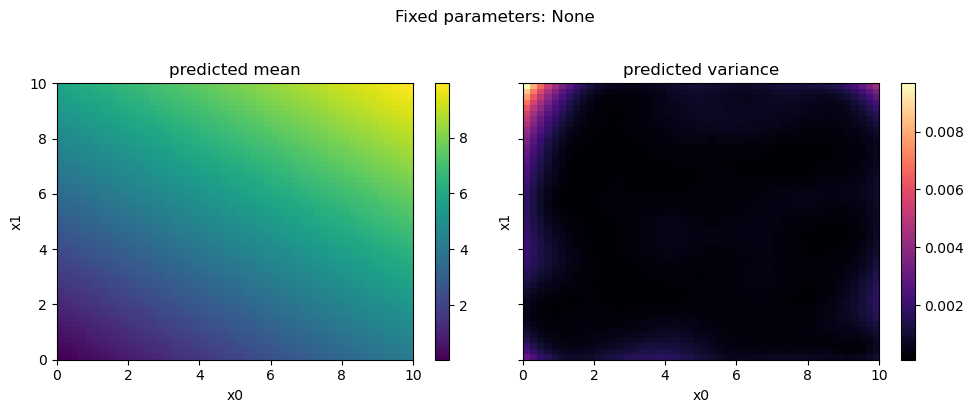

In [19]:
ae.plot_surface(best.model, parameters_range={"x0": [0, 10],"x1": [0, 10]}, quantile=0.5)

INFO    2026-01-15 14:43:39,021 - autoemulate - Using held out test data for calibration plot. To use different data, provide x_test and y_test.


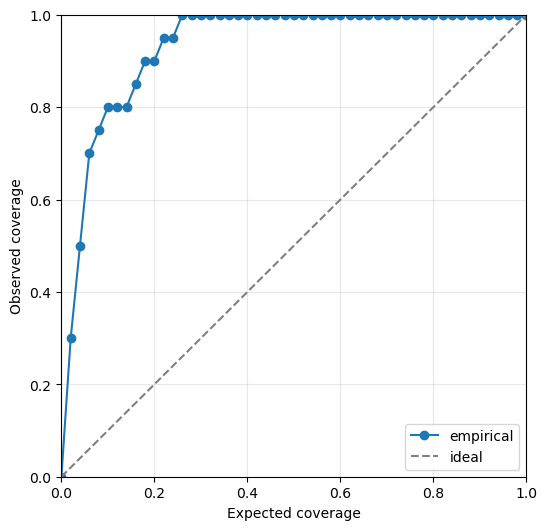

In [ ]:
ae.plot_calibration(best.model)

In [14]:
x_test = torch.tensor([[0.5, 0.5],
                          [1.0, 2.0],
                          [3.0, 4.0]], dtype=torch.float32)

print(best.model.predict(x_test).mean)
print(best.model.predict(x_test).stddev)

tensor([[0.5121],
        [1.5804],
        [3.5839]])
tensor([[0.0288],
        [0.0142],
        [0.0167]])


In [15]:
# y_sim_test = [simulate(xi.numpy().astype(np.float32)) for xi in x_test]
y_sim_test = [simulate(xi.tolist()) for xi in x_test]

print("Simulator outputs:", y_sim_test)


Simulator outputs: [np.float64(0.5000000000000004), np.float64(1.5833333333333357), np.float64(3.583333333333337)]


## Saving the emulator

In [ ]:
# Make a directory to save Emulator models
import os
path = "my_emulators"
if not os.path.exists(path):
    os.makedirs(path)

# The use_timestamp paramater ensures a new result is saved each time the save method is called
best_result_filepath = ae.save(best, path, use_timestamp=True)
print("Model and metadata saved to: ", best_result_filepath)

INFO    2026-01-15 15:26:50,224 - autoemulate - GaussianProcessMatern32_0_20260115_152650.joblib saved to my_emulators/GaussianProcessMatern32_0_20260115_152650
INFO    2026-01-15 15:26:50,226 - autoemulate - Metadata saved to my_emulators/GaussianProcessMatern32_0_20260115_152650_metadata.csv
Model and metadata saved to:  my_emulators/GaussianProcessMatern32_0_20260115_152650
